#### Importing Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

import time

#### Importing Datasets

In [6]:
%store -r Set1_X_Train_scaled
%store -r Set1_X_Test_scaled

%store -r Set1_y_Train
%store -r Set1_y_Test

#### KNN Regression (All Columns)

In [7]:
start = time.time()

Set1_y_Train_array = Set1_y_Train.values.ravel()
Set1_y_Test_array = Set1_y_Test.values.ravel()

knn_regressor = KNeighborsRegressor()

param_grid = {
    'n_neighbors': [3, 10, 50, 100, 250, 500],  
    'weights': ['uniform', 'distance'] 
}

grid_search = GridSearchCV(estimator=knn_regressor, param_grid=param_grid, cv=5, verbose=1, scoring='neg_mean_squared_error')

grid_search.fit(Set1_X_Train_scaled, Set1_y_Train_array)
end_grid_search = time.time()

best_params = grid_search.best_params_
print("Best Parameters:", best_params)

neg_mse = grid_search.best_score_
print("Negative Mean Squared Error:", neg_mse)

best_knn_regressor = KNeighborsRegressor(
                                    n_neighbors=best_params['n_neighbors'],
                                    weights=best_params['weights']) 
best_knn_regressor.fit(Set1_X_Train_scaled, Set1_y_Train_array)
end_train = time.time()  


start_predict = time.time()
knn_pred_train = best_knn_regressor.predict(Set1_X_Train_scaled)
end_predict = time.time()
knn_pred_test = best_knn_regressor.predict(Set1_X_Test_scaled)
end_predict_test = time.time()

knn_pred_train_int = knn_pred_train.astype(int)
knn_pred_test_int = knn_pred_test.astype(int)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'n_neighbors': 100, 'weights': 'distance'}
Negative Mean Squared Error: -1925.462870018103


#### KNN Evaluation

In [8]:
# Mean Squared Error
mse_train_knn = mean_squared_error(Set1_y_Train_array, knn_pred_train_int)
mse_test_knn = mean_squared_error(Set1_y_Test_array, knn_pred_test_int)

# Root Mean Squared Error
rmse_train_knn = np.sqrt(mse_train_knn)
rmse_test_knn = np.sqrt(mse_test_knn)

# Mean Absolute Error
mae_train_knn = mean_absolute_error(Set1_y_Train_array, knn_pred_train_int)
mae_test_knn = mean_absolute_error(Set1_y_Test_array, knn_pred_test_int)

# R2 Score
r2_train_knn = r2_score(Set1_y_Train_array, knn_pred_train_int)
r2_test_knn = r2_score(Set1_y_Test_array, knn_pred_test_int)

# Time
time_grid_search = end_grid_search - start
fit_time = end_train - end_grid_search
time_predict_train = end_predict - end_train
time_predict_test = end_predict_test - end_predict
total_time = end_predict_test - start

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_knn)
print("Root Mean Squared Error:", rmse_train_knn)
print("Mean Absolute Error:", mae_train_knn)
print("R-squared Score:", r2_train_knn)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_knn)
print("Root Mean Squared Error:", rmse_test_knn)
print("Mean Absolute Error:", mae_test_knn)
print("R-squared Score:", r2_test_knn)

# Time
print("\n--Fit, Training Times--")
print("Time for grid search:", "{:.2f}".format(time_grid_search), "seconds")
print("Time to fit:", "{:.2f}".format(fit_time), "seconds")
print("Time to predict (train set):", "{:.2f}".format(time_predict_train), "seconds")
print("Time to predict (test set):", "{:.2f}".format(time_predict_test), "seconds")
print("Total Time:", "{:.2f}".format(total_time), "seconds")

--Training Set Evaluation--
Mean Squared Error: 0.13416703019727594
Root Mean Squared Error: 0.3662881791667265
Mean Absolute Error: 0.13416703019727594
R-squared Score: 0.9999717207364925

--Testing Set Evaluation--
Mean Squared Error: 1211.36
Root Mean Squared Error: 34.80459739747035
Mean Absolute Error: 27.68
R-squared Score: 0.2985225983479006

--Fit, Training Times--
Time for grid search: 11.28 seconds
Time to fit: 0.00 seconds
Time to predict (train set): 0.51 seconds
Time to predict (test set): 0.01 seconds
Total Time: 11.80 seconds


#### Plot Evaluation Results

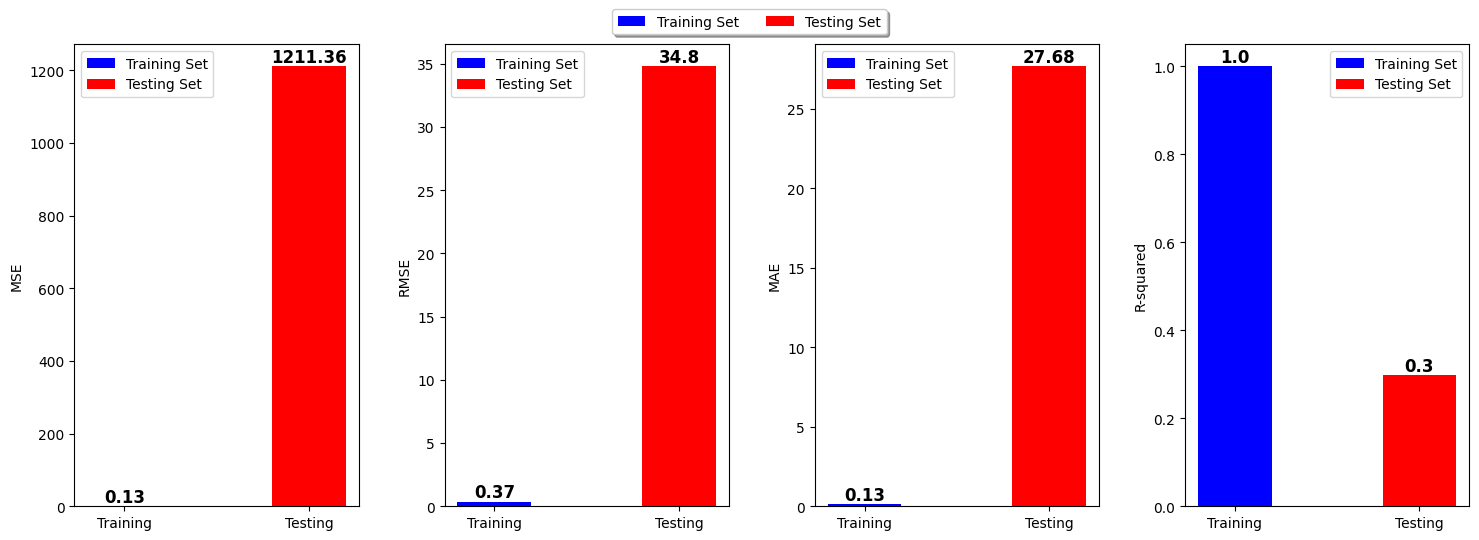

In [9]:
metrics = ['MSE', 'RMSE', 'MAE', 'R-squared']
train_metrics = [mse_train_knn, rmse_train_knn, mae_train_knn, r2_train_knn]
test_metrics = [mse_test_knn, rmse_test_knn, mae_test_knn, r2_test_knn]

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, (metric, train_metric, test_metric) in enumerate(zip(metrics, train_metrics, test_metrics)):
    ax = axes[i]
    ax.bar('Training', train_metric, color='b', label='Training Set', width=0.4)
    ax.bar('Testing', test_metric, color='r', label='Testing Set', width=0.4)
    ax.set_ylabel(metric)

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.legend()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), fancybox=True, shadow=True, ncol=2)

plt.subplots_adjust(wspace=0.3)
plt.show()

##### Plot Actual vs Predicted Values

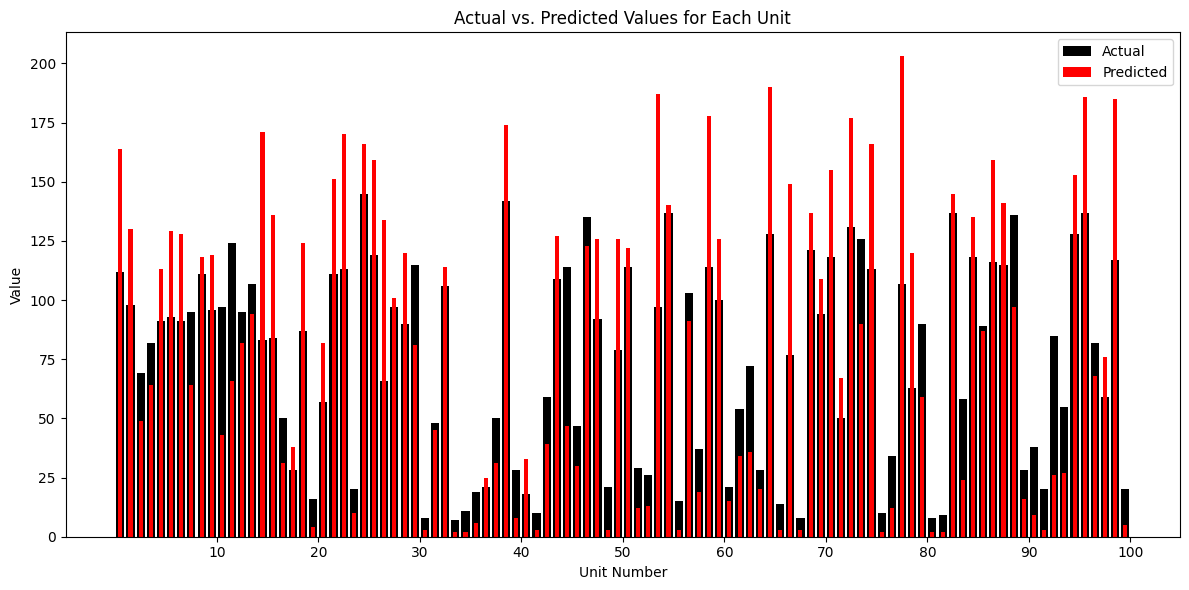

In [10]:
num_units = len(Set1_y_Test)
unit_numbers = np.arange(1, num_units + 1) 

actual_values = np.squeeze(Set1_y_Test)
predicted_values = np.squeeze(knn_pred_test_int)

fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.8
spacing = 1

ax.bar(unit_numbers - spacing/2, actual_values, bar_width, label='Actual', color='black')
ax.bar(unit_numbers - spacing/2, predicted_values, bar_width/2, label='Predicted', color='red')

ax.set_xlabel('Unit Number')
ax.set_ylabel('Value')
ax.set_title('Actual vs. Predicted Values for Each Unit')

tick_positions = np.arange(10, num_units + 1, 10)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(int(t)) for t in tick_positions]) 

ax.legend()
plt.tight_layout()
plt.show()

#### KNN (Dropped Constant, Highly Related Features, Applied Upper RUL Limit)

##### Import Dataset

In [11]:
%store -r FD1_X_Train_sc
%store -r FD1_X_Test_sc
%store -r FD1_y_Train
%store -r FD1_y_Test

#### KNN Regressor

In [14]:
start = time.time()

FD1_y_Train_array = FD1_y_Train.values.ravel()
FD1_y_Test_array = FD1_y_Test.values.ravel()

knn_regressor_new = KNeighborsRegressor()

param_grid = {
    'n_neighbors': [3, 10, 50, 100, 250, 500],  
    'weights': ['uniform', 'distance'] 
}

grid_search_new = GridSearchCV(estimator=knn_regressor_new, param_grid=param_grid, cv=5, verbose=1, scoring='neg_mean_squared_error')

grid_search_new.fit(FD1_X_Train_sc, FD1_y_Train_array)
end_grid_search = time.time()

best_params_new = grid_search_new.best_params_
print("Best Parameters:", best_params_new)

neg_mse_new = grid_search_new.best_score_
print("Negative Mean Squared Error:", neg_mse_new)

knn_regressor_new = KNeighborsRegressor(
                                    n_neighbors=best_params['n_neighbors'],
                                    weights=best_params['weights']) 
knn_regressor_new.fit(FD1_X_Train_sc, FD1_y_Train_array)
end_train = time.time()  

knn_pred_train_new = knn_regressor_new.predict(FD1_X_Train_sc)
end_predict = time.time()
knn_pred_test_new = knn_regressor_new.predict(FD1_X_Test_sc)
end_predict_test = time.time()

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'n_neighbors': 50, 'weights': 'distance'}
Negative Mean Squared Error: -326.06844651276884


#### KNN Evaluation

In [15]:
# Mean Squared Error
mse_train_knn_new = mean_squared_error(FD1_y_Train_array_new, knn_pred_train_new)
mse_test_knn_new = mean_squared_error(FD1_y_Test_array_new, knn_pred_test_new)

# Root Mean Squared Error
rmse_train_knn_new = np.sqrt(mse_train_knn_new)
rmse_test_knn_new = np.sqrt(mse_test_knn_new)

# Mean Absolute Error
mae_train_knn_new = mean_absolute_error(FD1_y_Train_array_new, knn_pred_train_new)
mae_test_knn_new = mean_absolute_error(FD1_y_Test_array_new, knn_pred_test_new)

# R2 Score
r2_train_knn_new = r2_score(FD1_y_Train_array_new, knn_pred_train_new)
r2_test_knn_new = r2_score(FD1_y_Test_array_new, knn_pred_test_new)

# Time
time_grid_search = end_grid_search - start
fit_time = end_train - end_grid_search
time_predict_train = end_predict - end_train
time_predict_test = end_predict_test - end_predict
total_time = end_predict_test - start

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_knn_new)
print("Root Mean Squared Error:", rmse_train_knn_new)
print("Mean Absolute Error:", mae_train_knn_new)
print("R-squared Score:", r2_train_knn_new)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_knn_new)
print("Root Mean Squared Error:", rmse_test_knn_new)
print("Mean Absolute Error:", mae_test_knn_new)
print("R-squared Score:", r2_test_knn_new)

# Time
print("\n--Fit, Training Times--")
print("Time for grid search:", "{:.2f}".format(time_grid_search), "seconds")
print("Time to fit:", "{:.2f}".format(fit_time), "seconds")
print("Time to predict (train set):", "{:.2f}".format(time_predict_train), "seconds")
print("Time to predict (test set):", "{:.2f}".format(time_predict_test), "seconds")
print("Total Time:", "{:.2f}".format(total_time), "seconds")

--Training Set Evaluation--
Mean Squared Error: 0.0
Root Mean Squared Error: 0.0
Mean Absolute Error: 0.0
R-squared Score: 1.0

--Testing Set Evaluation--
Mean Squared Error: 551.5709968165836
Root Mean Squared Error: 23.485548680339228
Mean Absolute Error: 18.63531645559115
R-squared Score: 0.6805948771021368

--Fit, Training Times--
Time for grid search: 63.94 seconds
Time to fit: 0.02 seconds
Time to predict (train set): 5.63 seconds
Time to predict (test set): 0.03 seconds
Total Time: 69.63 seconds


#### Plot Evaluation Results

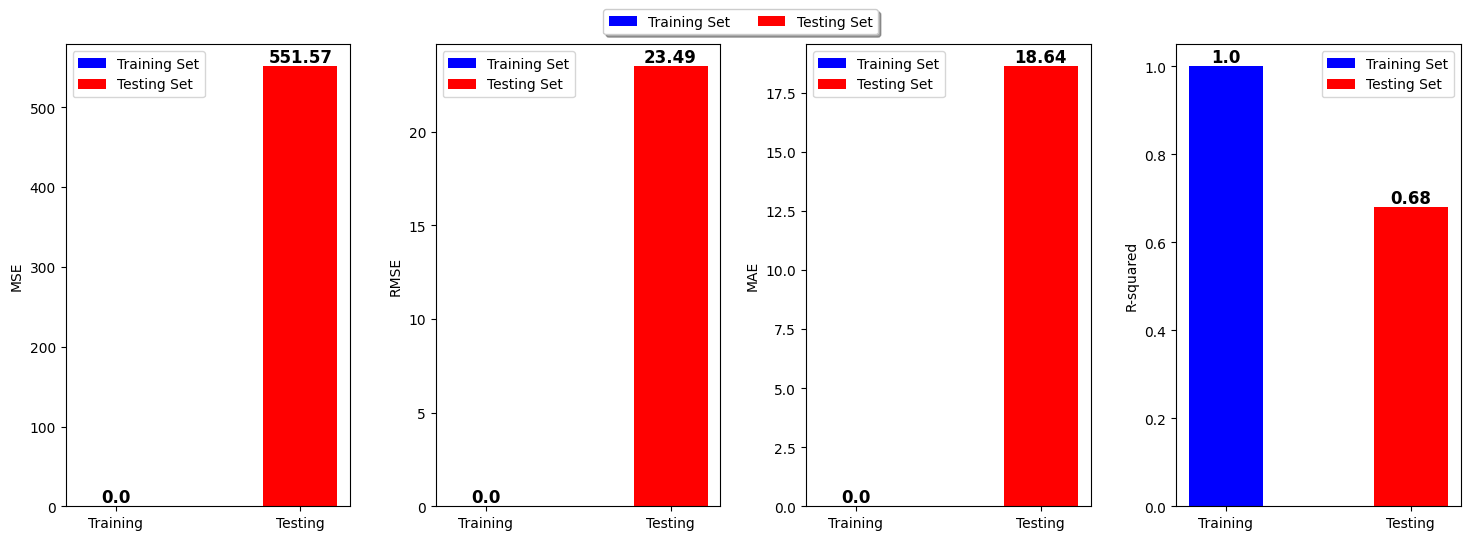

In [16]:
metrics = ['MSE', 'RMSE', 'MAE', 'R-squared', 'Total-Time']
train_metrics = [mse_train_knn_new, rmse_train_knn_new, mae_train_knn_new, r2_train_knn_new]
test_metrics = [mse_test_knn_new, rmse_test_knn_new, mae_test_knn_new, r2_test_knn_new]

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, (metric, train_metric, test_metric) in enumerate(zip(metrics, train_metrics, test_metrics)):
    ax = axes[i]
    ax.bar('Training', train_metric, color='b', label='Training Set', width=0.4)
    ax.bar('Testing', test_metric, color='r', label='Testing Set', width=0.4)
    ax.set_ylabel(metric)

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.legend()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), fancybox=True, shadow=True, ncol=2)

plt.subplots_adjust(wspace=0.3)
plt.show()

#### Plot Actual vs Predicted Values

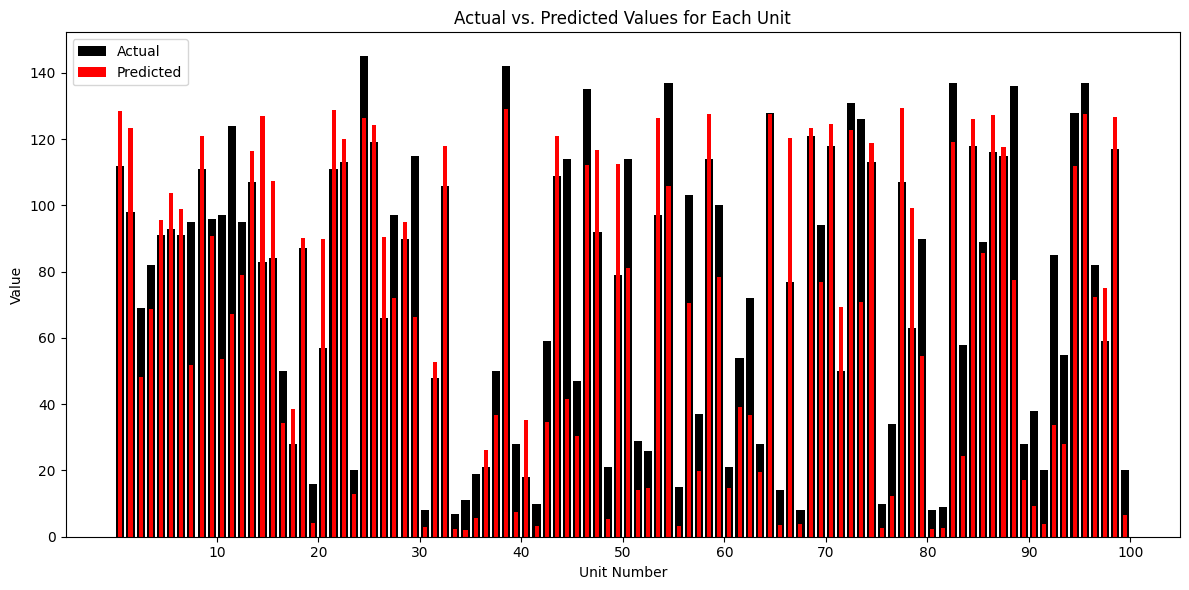

In [17]:
num_units = len(FD1_y_Test_array_new)
unit_numbers = np.arange(1, num_units + 1) 

actual_values = np.squeeze(FD1_y_Test_array_new)
predicted_values = np.squeeze(knn_pred_test_new)

fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.8
spacing = 1

ax.bar(unit_numbers - spacing/2, actual_values, bar_width, label='Actual', color='black')
ax.bar(unit_numbers - spacing/2, predicted_values, bar_width/2, label='Predicted', color='red')

ax.set_xlabel('Unit Number')
ax.set_ylabel('Value')
ax.set_title('Actual vs. Predicted Values for Each Unit')

tick_positions = np.arange(10, num_units + 1, 10)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(int(t)) for t in tick_positions]) 

ax.legend()
plt.tight_layout()
plt.show()

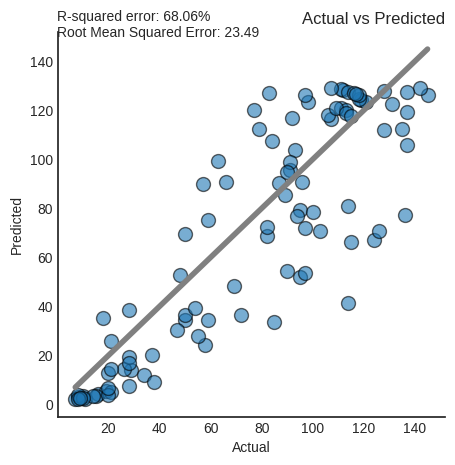

In [18]:
plt.style.use('seaborn-white')
plt.rcParams['figure.figsize']=5,5 

fig,ax = plt.subplots()
plt.title('Actual vs Predicted', loc='right')
plt.xlabel('Actual')
plt.ylabel('Predicted')
g = sns.scatterplot(x=FD1_y_Test_array_new,
                y=knn_pred_test_new,
                s=100,
                alpha=0.6,
                linewidth=1,
                edgecolor='black',
                ax=ax)
f = sns.lineplot(x=[min(FD1_y_Test_array_new),max(FD1_y_Test_array_new)],
             y=[min(FD1_y_Test_array_new),max(FD1_y_Test_array_new)],
             linewidth=4,
             color='gray',
             ax=ax)

plt.annotate(text=('R-squared error: '+ "{:.2%}".format(knn_regressor_new.score(FD1_X_Test_sc,FD1_y_Test_array_new)) +'\n' +
                  'Root Mean Squared Error: '+ "{:.2f}".format(mean_squared_error(FD1_y_Test_array_new,knn_pred_test_new,squared=False))),
             xy=(0,150),
             size='medium')

xlabels = ['{:,.0f}'.format(x) for x in g.get_xticks()]
g.set_xticklabels(xlabels)
ylabels = ['{:,.0f}'.format(x) for x in g.get_yticks()]
g.set_yticklabels(ylabels)
sns.despine()

##### Last 5 Cycles from X_Test

In [19]:
%store -r Last_5_X_Test
%store -r Last_5_X_Test_sc

In [20]:
start = time.time()

FD1_y_Train_array = FD1_y_Train.values.ravel()
FD1_y_Test_array = FD1_y_Test.values.ravel()

knn_regressor_new = KNeighborsRegressor()

param_grid = {
    'n_neighbors': [3, 10, 50, 100, 250, 500],  
    'weights': ['uniform', 'distance'] 
}

grid_search_new = GridSearchCV(estimator=knn_regressor_new, param_grid=param_grid, cv=5, verbose=1, scoring='neg_mean_squared_error')

grid_search_new.fit(FD1_X_Train_sc, FD1_y_Train_array)
end_grid_search = time.time()

best_params_new = grid_search_new.best_params_
print("Best Parameters:", best_params_new)

neg_mse_new = grid_search_new.best_score_
print("Negative Mean Squared Error:", neg_mse_new)

knn_regressor_new = KNeighborsRegressor(
                                    n_neighbors=best_params['n_neighbors'],
                                    weights=best_params['weights']) 
knn_regressor_new.fit(FD1_X_Train_sc, FD1_y_Train_array)
end_train = time.time()  

knn_pred_train_new = knn_regressor_new.predict(FD1_X_Train_sc)
end_predict = time.time()
knn_pred_test_new = knn_regressor_new.predict(Last_5_X_Test_sc)
end_predict_test = time.time()

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'n_neighbors': 50, 'weights': 'distance'}
Negative Mean Squared Error: -326.06844651276884


In [21]:
knn_new_pred_test_reshaped = knn_pred_test_new.reshape(-1, 5)
average_rul_per_group = np.mean(knn_new_pred_test_reshaped, axis=1)

In [22]:
# Mean Squared Error
mse_train_knn_new = mean_squared_error(FD1_y_Train_array_new, knn_pred_train_new)
mse_test_knn_new = mean_squared_error(FD1_y_Test_array_new, average_rul_per_group)

# Root Mean Squared Error
rmse_train_knn_new = np.sqrt(mse_train_knn_new)
rmse_test_knn_new = np.sqrt(mse_test_knn_new)

# Mean Absolute Error
mae_train_knn_new = mean_absolute_error(FD1_y_Train_array_new, knn_pred_train_new)
mae_test_knn_new = mean_absolute_error(FD1_y_Test_array_new, average_rul_per_group)

# R2 Score
r2_train_knn_new = r2_score(FD1_y_Train_array_new, knn_pred_train_new)
r2_test_knn_new = r2_score(FD1_y_Test_array_new, average_rul_per_group)

# Time
time_grid_search = end_grid_search - start
fit_time = end_train - end_grid_search
time_predict_train = end_predict - end_train
time_predict_test = end_predict_test - end_predict
total_time = end_predict_test - start

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_knn_new)
print("Root Mean Squared Error:", rmse_train_knn_new)
print("Mean Absolute Error:", mae_train_knn_new)
print("R-squared Score:", r2_train_knn_new)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_knn_new)
print("Root Mean Squared Error:", rmse_test_knn_new)
print("Mean Absolute Error:", mae_test_knn_new)
print("R-squared Score:", r2_test_knn_new)

# Time
print("\n--Fit, Training Times--")
print("Time for grid search:", "{:.2f}".format(time_grid_search), "seconds")
print("Time to fit:", "{:.2f}".format(fit_time), "seconds")
print("Time to predict (train set):", "{:.2f}".format(time_predict_train), "seconds")
print("Time to predict (test set):", "{:.2f}".format(time_predict_test), "seconds")
print("Total Time:", "{:.2f}".format(total_time), "seconds")

--Training Set Evaluation--
Mean Squared Error: 0.0
Root Mean Squared Error: 0.0
Mean Absolute Error: 0.0
R-squared Score: 1.0

--Testing Set Evaluation--
Mean Squared Error: 476.39953119146935
Root Mean Squared Error: 21.826578549820155
Mean Absolute Error: 16.539917184763187
R-squared Score: 0.7241253588623777

--Fit, Training Times--
Time for grid search: 64.82 seconds
Time to fit: 0.03 seconds
Time to predict (train set): 5.81 seconds
Time to predict (test set): 0.16 seconds
Total Time: 70.81 seconds
